In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("demo_2x2.pkl", "rb") as f:
    results = pickle.load(f)

t_arr = np.array([r["t"] for r in results])
n_turbines = 4

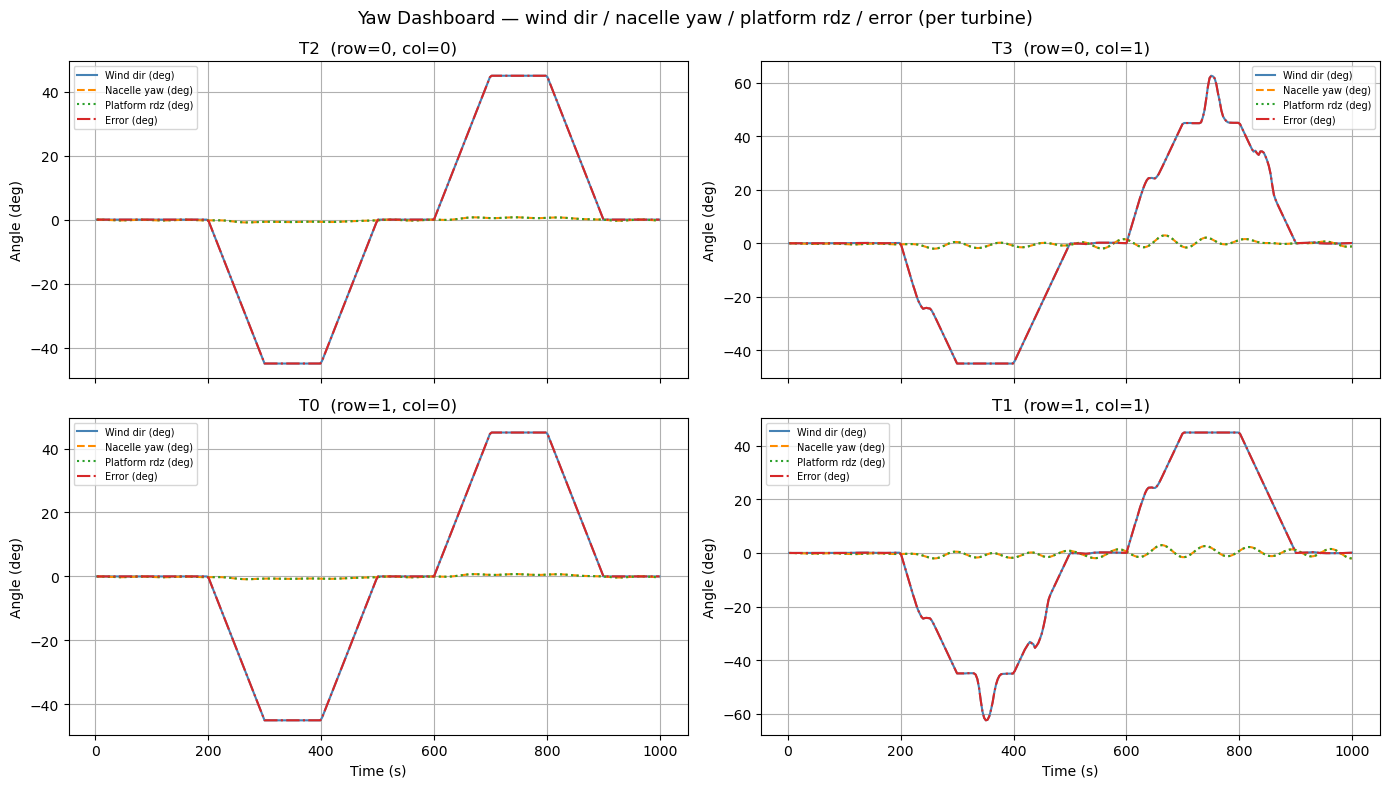

In [2]:
# Farm layout (from 2x2.fstf): wind flows in +X direction
#   row 0 (top,    Y=630): T2 (upstream)  | T3 (downstream)
#   row 1 (bottom, Y=0  ): T0 (upstream)  | T1 (downstream)
turb_to_ax = {0: (1, 0), 1: (1, 1), 2: (0, 0), 3: (0, 1)}
fig_yaw, axes_yaw = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig_yaw.suptitle("Yaw Dashboard — wind dir / nacelle yaw / platform rdz / error (per turbine)", fontsize=13)

for i in range(n_turbines):
    row, col = turb_to_ax[i]
    ax = axes_yaw[row][col]

    wind_dir = np.array([r[f"wind_dir_T{i}"]      for r in results]) - 270         # convert to 0°=from left, +CCW
    yaw_meas = (np.array([r[f"yaw_T{i}"]          for r in results]))
    rdz      = (np.array([r[f"platform_rdz_T{i}"] for r in results]))
    error    = wind_dir - (yaw_meas - rdz)  

    ax.plot(t_arr, wind_dir, label="Wind dir (deg)",    color="steelblue")
    ax.plot(t_arr, yaw_meas, label="Nacelle yaw (deg)", color="darkorange",  linestyle="--")
    ax.plot(t_arr, rdz,      label="Platform rdz (deg)",color="tab:green",   linestyle=":")
    ax.plot(t_arr, error,    label="Error (deg)",        color="tab:red",     linestyle="-.")
    ax.set_title(f"T{i}  (row={row}, col={col})")
    ax.set_ylabel("Angle (deg)")
    if row == 1:
        ax.set_xlabel("Time (s)")
    ax.legend(fontsize=7)
    ax.grid(True)
fig_yaw.tight_layout()
plt.show()